In [427]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyreadstat import read_sav
from pyreadstat import metadata_container

np.random.seed(42)

In [428]:
df: pd.DataFrame; meta: metadata_container
df, meta = read_sav('data.sav')
df = df.drop('k4_new', axis=1)
print(df.shape)
df.head()

(2695, 22)


,Cреднеспис.числ.работн,k1,k2,k3,k4,k5,k6,k7,k8,k9,k10,k11,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
0,6095.0,0.942380,0.060563,0.678302,-0.161531,0.202055,0.165019,0.399033,0.799019,5.426569,0.209235,1.115922,1.082798,0.655937,4.454819,3.975687,0.892446,1007.536232,0.076738,0.055049,0.034904,5.0
1,255.0,1.980494,0.274382,0.916775,0.624425,0.089377,0.220648,0.000000,0.933519,14.041958,0.215083,1.259382,1.123828,0.705951,10.618881,12.295547,1.157895,357.294118,0.116068,0.059740,0.025647,5.0
2,114.0,0.374160,0.001494,0.085138,-1.504990,0.235739,0.508929,0.888889,0.779049,5.017007,0.096737,0.774586,1.185374,0.123415,0.794785,6.258929,7.875000,36.894737,-0.584879,0.010563,0.000000,5.0
3,365.0,7.859079,0.831978,2.449864,0.875862,0.059439,0.030030,0.011111,0.942010,16.244444,0.876663,1.223284,1.309449,2.804607,48.363889,26.142643,0.540541,33.676983,0.171731,0.496295,0.312415,5.0
4,168.0,1.779376,0.005596,0.883293,0.527853,0.135491,0.886686,0.489796,0.887341,10.558673,0.313389,0.874381,0.994832,0.473041,5.628827,3.125354,0.555241,19.103896,0.064809,0.025726,0.011839,5.0


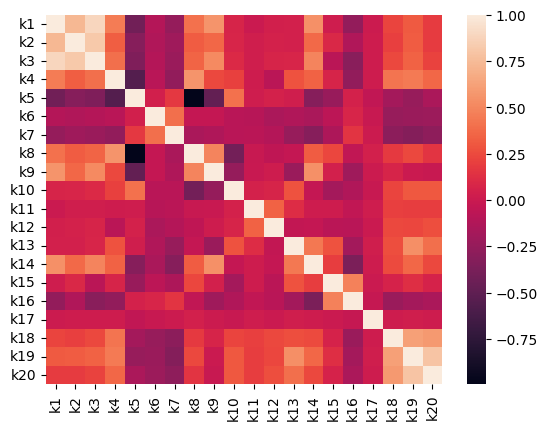

In [429]:
sns.heatmap(df[df.columns[1:-1]].corr())
plt.show()

df = df.drop('k8', axis=1)
NUM_COLS = df.columns[1:-1]

Нахождение выбросов (Isolation forest)

In [430]:
from sklearn.ensemble import IsolationForest

df_train: pd.DataFrame; df_test: pd.DataFrame
print(f"Shape: {df.shape}")

clf = IsolationForest(
    n_estimators=500,           # Больше деревьев = стабильнее
    max_samples='auto',         # Можно попробовать 256, 512, 1024
    contamination='auto',       # или 0.05, или подобрать вручную
    max_features=0.8,           # Используем не все признаки сразу (боремся с шумом)
    bootstrap=False,
    random_state=42
)

clf.fit(df[NUM_COLS])
outliers_train: np.ndarray = clf.predict(df[NUM_COLS])

print(f"Number of outliers in df: {np.abs( outliers_train[outliers_train == -1].sum() )}")

Shape: (2695, 21)
Number of outliers in df: 136


Винсоризация:

In [431]:
outliers_mask = (outliers_train == -1)

percentiles = {}
for col in NUM_COLS:
    p_low: float = df[col][outliers_mask != 1].min()
    p_high = df[col][outliers_mask != 1].max()
    percentiles[col] = (p_low, p_high)

df_clean: pd.DataFrame = df.copy()
for col in NUM_COLS:
    low, high = percentiles[col]
    col_data = df_clean[col][outliers_mask]
    col_data[col_data < low] = low
    col_data[col_data > high] = high
    df_clean.loc[outliers_mask, col] = col_data

    
#df_clean = df[outliers_mask != 1]


Стандартизация:

In [432]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df_clean)

df_array: np.ndarray = scaler.transform(df_clean)
df_stand: pd.DataFrame = pd.DataFrame(df_array,
                                             columns=df_clean.columns,
                                               index=df_clean.index)


Метод главных компонент:

In [433]:
from sklearn.decomposition import PCA

n_pca_components: int = 6
total_variance = np.sum(np.var(df_stand[NUM_COLS], axis=0, ddof=1))

pca = PCA(n_components=n_pca_components, random_state=42)
pca.fit(df_stand[NUM_COLS])
pca_eigen_values: np.ndarray = pca.explained_variance_

pca_res_df = pd.DataFrame(
    {"Eigen values": pca_eigen_values,
        "Explained variance ratio": pca.explained_variance_ratio_,
            "Cumsum of explained variance ratio": np.cumsum(pca.explained_variance_ratio_)},
    index=[i for i in range(n_pca_components)]
)
print(pca_res_df)

pca_array: np.ndarray = pca.transform(df_stand[NUM_COLS])
pca_columns: list[str] = ['pca_' + str(i + 1) for i in range(n_pca_components)]
df_pca: pd.DataFrame = pd.DataFrame(pca_array, columns=pca_columns, index=df_stand.index)
print("\nDataframe in principal components space:")
print(f"Shape: {df_pca.shape}")
print(df_pca.head())

   Eigen values  Explained variance ratio  Cumsum of explained variance ratio
0      5.131626                  0.269985                            0.269985
1      2.746323                  0.144490                            0.414475
2      1.724670                  0.090738                            0.505213
3      1.412437                  0.074311                            0.579525
4      1.156782                  0.060861                            0.640385
5      1.132669                  0.059592                            0.699977

Dataframe in principal components space:
Shape: (2695, 6)
      pca_1     pca_2     pca_3     pca_4     pca_5     pca_6
0 -1.062975  0.606016 -0.354002  0.288986 -0.852363  0.689220
1  0.892079  1.388750  0.435714  0.423050 -1.109801  0.258063
2 -5.405600  2.756024  0.156487 -0.176024  1.581223  1.062442
3  7.849036 -0.055441  1.447470 -1.429823 -0.342704 -0.477656
4 -1.023884  2.026061 -0.818490 -0.882516 -0.795567  3.037570


In [434]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loadings_df = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_stand[NUM_COLS].columns
)

print(loadings_df[loadings_df >= 0.5])

          PC1       PC2       PC3       PC4      PC5       PC6
k1   0.765868       NaN       NaN       NaN      NaN       NaN
k2   0.686758       NaN       NaN       NaN      NaN       NaN
k3   0.771632       NaN       NaN       NaN      NaN       NaN
k4   0.678220       NaN       NaN       NaN      NaN       NaN
k5        NaN       NaN       NaN       NaN      NaN       NaN
k6        NaN       NaN       NaN       NaN      NaN  0.629503
k7        NaN       NaN       NaN       NaN      NaN  0.522829
k9        NaN  0.672864       NaN       NaN      NaN       NaN
k10       NaN       NaN       NaN       NaN      NaN       NaN
k11       NaN       NaN       NaN  0.576104      NaN       NaN
k12       NaN       NaN       NaN  0.710528      NaN       NaN
k13       NaN       NaN       NaN       NaN      NaN       NaN
k14  0.691285       NaN       NaN       NaN      NaN       NaN
k15       NaN       NaN  0.862980       NaN      NaN       NaN
k16       NaN       NaN  0.591947       NaN  0.56405   

In [435]:
from factor_analyzer import Rotator

rotator = Rotator(method='varimax')
rotated_loadings = rotator.fit_transform(loadings)

rotated_eig_vals = np.sum(rotated_loadings**2, axis=0)      # сумма квадратов по строкам (признакам)

components = [f"PC{i+1}_rot" for i in range(len(rotated_eig_vals))]
df_eigen = pd.DataFrame({
    "Component": components,
    "Eigenvalue": rotated_eig_vals,
    "Variance %": (rotated_eig_vals / total_variance) * 100,
    "Cumulative %": np.cumsum(rotated_eig_vals / total_variance) * 100
})
print(df_eigen)

  Component  Eigenvalue  Variance %  Cumulative %
0   PC1_rot    3.406770   17.923718     17.923718
1   PC2_rot    3.300177   17.362906     35.286624
2   PC3_rot    1.582546    8.326100     43.612724
3   PC4_rot    1.563463    8.225702     51.838425
4   PC5_rot    1.842879    9.695765     61.534190
5   PC6_rot    1.608672    8.463551     69.997741


In [436]:
df_rotated_loadings = pd.DataFrame(
    rotated_loadings,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_stand[NUM_COLS].columns
)
print(df_rotated_loadings[df_rotated_loadings >= 0.5])

          PC1  PC2       PC3       PC4       PC5       PC6
k1   0.906191  NaN       NaN       NaN       NaN       NaN
k2   0.892241  NaN       NaN       NaN       NaN       NaN
k3   0.917426  NaN       NaN       NaN       NaN       NaN
k4        NaN  NaN       NaN       NaN       NaN       NaN
k5        NaN  NaN       NaN       NaN  0.781383       NaN
k6        NaN  NaN       NaN       NaN       NaN  0.747616
k7        NaN  NaN       NaN       NaN       NaN  0.716779
k9   0.573435  NaN       NaN       NaN       NaN       NaN
k10       NaN  NaN       NaN       NaN  0.712819       NaN
k11       NaN  NaN       NaN  0.653213       NaN       NaN
k12       NaN  NaN       NaN  0.806757       NaN       NaN
k13       NaN  NaN       NaN       NaN       NaN       NaN
k14       NaN  NaN       NaN       NaN       NaN       NaN
k15       NaN  NaN  0.827378       NaN       NaN       NaN
k16       NaN  NaN  0.853621       NaN       NaN       NaN
k17       NaN  NaN       NaN       NaN       NaN       N

In [ ]:
from sklearn.decomposition import FactorAnalysis

fa = FactorAnalysis(n_components=n_pca_components, rotation='varimax', random_state=42)
fa.fit(df_stand[NUM_COLS])
#print(fa.components_)
fa_loadings = fa.components_.T
loadings_df = pd.DataFrame(
    fa_loadings,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_stand[NUM_COLS].columns
)

print(np.sum(fa_loadings ** 2, axis=0))
print(loadings_df[loadings_df >= 0.5])

Собственный МГК:

In [ ]:
from principal_component_analysis import SVDPCA

svdpca = SVDPCA(n_components=5)
svdpca.fit(df_stand[NUM_COLS])

[4.94656528 2.58559454 1.79311478 1.44213192 1.20233095 1.14480798
 0.99595539 0.89614086 0.72722426 0.59971625 0.58513458 0.55956112
 0.45213444 0.33974086 0.2474558  0.15947461 0.12586357 0.1015361
 0.09551671]


Добавление интегрального показателя:

In [ ]:
integral_score = np.zeros(df_pca.shape[0])
for i, col in enumerate(df_pca.columns):
    integral_score += df_pca[col] * (pca_eigen_values[i] / total_variance)

#integral_score_normalized = 50 + (integral_score - integral_score.mean()) / integral_score.std() * 10
df_final = df_stand.copy()
df_final['int_score'] = integral_score

Количество найденных кластеров: 4
Количество точек, отнесённых к шуму: 0
Метки кластеров (первые 10): [3 2 3 3 0 3 0 2 2 3]

Число наблюдений в каждом кластере:
0 331
1 692
2 769
3 767


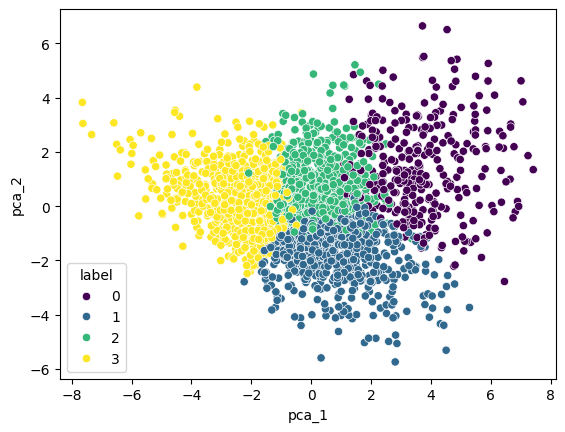

In [ ]:
from sklearn.cluster import HDBSCAN
from sklearn.cluster import KMeans

#clusterer = HDBSCAN(min_cluster_size=50, copy=False)
clusterer = KMeans(n_clusters=4, random_state=42)
clusterer.fit(df_pca)

# Результаты
labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # -1 метка для шума
n_noise = list(labels).count(-1)

print(f"Количество найденных кластеров: {n_clusters}")
print(f"Количество точек, отнесённых к шуму: {n_noise}")
print(f"Метки кластеров (первые 10): {labels[:10]}")
print("\nЧисло наблюдений в каждом кластере:")
#print(clusterer.probabilities_[:10])
for i in set(labels):
    print(i, np.sum(labels == i))

df_final['label'] = labels
#plt.scatter(df_pca['pca_1'], df_pca['pca_2'], с=labels, cmap='viridis')
sns.scatterplot(df_pca, x='pca_1', y='pca_2', hue=df_final['label'], palette='viridis')
plt.show()

In [ ]:
for i in range(4):
    print(df_final[df_final['label'] == i]['int_score'].mean())

1.1099345919528527
-0.06937094703975995
0.1590135425581272
-0.5758345095333509
